# Week 4 Day 3 — PCA Loading Vectors

Plots `pca.components_[0, 1, 2]` as functions of maturity and verifies the
Litterman-Scheinkman level/slope/curvature interpretation.

`pca.components_[i]` is a vector of 8 numbers — one per maturity — saying how much
each maturity participates when factor *i* moves by one unit. The expected shapes:

| Factor | Shape | Interpretation |
|--------|-------|----------------|
| PC1 | flat (all same sign) | *level* — all rates move together |
| PC2 | monotonic (sign flip from short to long) | *slope* — short vs. long |
| PC3 | U-shaped or inverted-U | *curvature* — belly vs. wings |

**Sign convention:** sklearn doesn't fix the sign of each component — PC1 might
be all-negative instead of all-positive. The shape matters, not the sign.

In [1]:
import sys
sys.path.insert(0, '../src')

import joblib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from termstructure.pca.panel import DEFAULT_MATURITIES

pca = joblib.load('../data/processed/pca_model.joblib')
maturities = DEFAULT_MATURITIES
print(f'Components shape: {pca.components_.shape}  (n_components × n_maturities)')
print(f'Maturities: {maturities}')

Components shape: (8, 8)  (n_components × n_maturities)
Maturities: [1, 2, 3, 5, 7, 10, 20, 30]


## 1. First three loading vectors

Each subplot shows one PC's loadings across the yield curve.
The *shape* of the line is the diagnostic — ignore the sign.

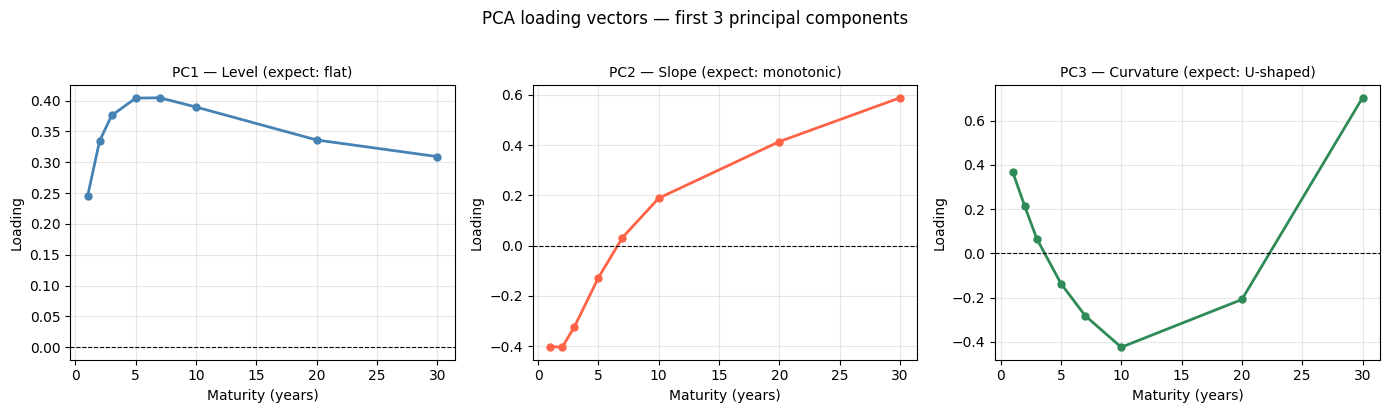

In [2]:
titles  = ['PC1 — Level (expect: flat)', 'PC2 — Slope (expect: monotonic)', 'PC3 — Curvature (expect: U-shaped)']
colors  = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i, (ax, title, color) in enumerate(zip(axes, titles, colors)):
    loadings = pca.components_[i]
    ax.plot(maturities, loadings, marker='o', ms=5, lw=2, color=color)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Loading')
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA loading vectors — first 3 principal components', y=1.02)
plt.tight_layout()
plt.savefig('data/week4_day3_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Shape diagnostics

Automated checks for the expected loading shapes.
All three should pass — if not, go back and check the zero panel.

In [3]:
pc1 = pca.components_[0]
pc2 = pca.components_[1]
pc3 = pca.components_[2]

# PC1: all same sign (level) — sign may be negative, so check abs dominance
level_ok = (pc1 > 0).all() or (pc1 < 0).all()
print(f'PC1 level (all same sign):  {"PASS" if level_ok else "FAIL"}')

# PC2: monotonic from short to long (or reverse) — one sign change allowed
diffs = np.diff(pc2)
sign_changes = np.sum(np.diff(np.sign(diffs)) != 0)
slope_ok = sign_changes <= 1
print(f'PC2 slope (monotonic):      {"PASS" if slope_ok else "FAIL"}  ({sign_changes} sign changes in diffs)')

# PC3: U-shaped — minimum (or maximum) somewhere in the middle, not at the ends
mid = len(pc3) // 2
curvature_ok = (
    abs(pc3[mid]) > abs(pc3[0]) * 0.3   # middle is active
    and not (abs(pc3[0]) > abs(pc3[mid]) * 3)  # ends aren't completely dominant
)
print(f'PC3 curvature (U-shaped):   {"PASS" if curvature_ok else "FAIL"}')

PC1 level (all same sign):  PASS
PC2 slope (monotonic):      PASS  (1 sign changes in diffs)
PC3 curvature (U-shaped):   PASS


## 3. All 8 components (heatmap)

A heatmap of the full loading matrix. The first 3 rows should have clear structure;
rows 4–8 should look like noise (they collectively explain ~1% of variance).

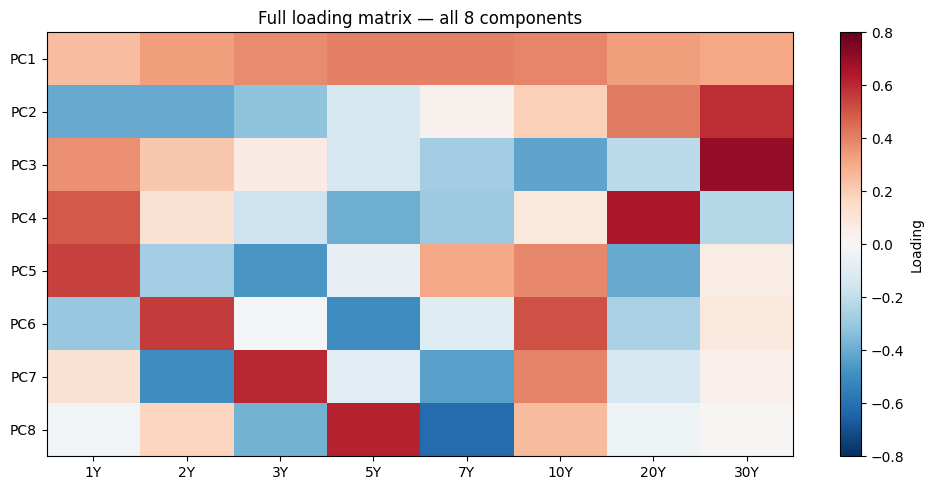

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pca.components_, aspect='auto', cmap='RdBu_r',
               vmin=-0.8, vmax=0.8)
plt.colorbar(im, ax=ax, label='Loading')
ax.set_xticks(range(len(maturities)))
ax.set_xticklabels([f'{m}Y' for m in maturities])
ax.set_yticks(range(pca.n_components_))
ax.set_yticklabels([f'PC{i+1}' for i in range(pca.n_components_)])
ax.set_title('Full loading matrix — all 8 components')
plt.tight_layout()
plt.show()